# 10 — Sales forecasting baseline

**Business objective**: before reaching for XGBoost, Prophet, or a neural
forecaster, establish honest baseline models for monthly revenue. A
"sophisticated" model that can't beat `next month = this month` isn't
adding value — it's adding complexity. This notebook exists to set that
floor, in writing, before Milestone 4 tries to beat it.

**This notebook is not**: the final forecasting model. It's the number
every future model has to justify itself against.

**Contract**: reads only `data/analytics/monthly_sales.csv` (never raw
data, never other analytics tables), writes only to `data/predictions/`
and `models/`, and runs top-to-bottom with no manual steps.

## Why baseline models matter

In a real forecasting project, the single most common failure mode isn't
"the model wasn't fancy enough" — it's *skipping the baseline entirely*
and never finding out that a naive forecast was 90% as good as the complex
model that took three weeks to build. Baselines are cheap insurance: they
tell you the size of the problem before you commit engineering time to
solving it, and they give you a number to defend when a stakeholder asks
"how do you know this model is actually helping?"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 4)

ANALYTICS_DIR = Path("../data/analytics")
PRED_DIR = Path("../data/predictions")
MODEL_DIR = Path("../models")
PRED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading from : {(ANALYTICS_DIR / 'monthly_sales.csv').resolve()}")
print(f"Predictions to: {PRED_DIR.resolve()}")
print(f"Model to     : {MODEL_DIR.resolve()}")

Reading from : /home/claude/project/eaida/data/analytics/monthly_sales.csv
Predictions to: /home/claude/project/eaida/data/predictions
Model to     : /home/claude/project/eaida/models


In [2]:
monthly = pd.read_csv(ANALYTICS_DIR / "monthly_sales.csv")
monthly["month"] = pd.to_datetime(monthly["month"], format="%Y-%m")
monthly = monthly.sort_values("month").reset_index(drop=True)

# Same convention established in Day 3/4 findings (docs/data/day3_findings.md,
# day4_findings.md): the most recent month is partial because data generation
# stops at "today", not at a real month-end. 2026-07 has 92 orders vs ~2,300
# in a normal month -- including it as a forecast target would corrupt both
# the features and the evaluation metrics. Drop it, don't just note it.
last_month_orders = monthly["orders"].iloc[-1]
typical_orders = monthly["orders"].iloc[-7:-1].mean()
if last_month_orders < 0.5 * typical_orders:
    dropped_month = monthly["month"].iloc[-1]
    monthly = monthly.iloc[:-1].reset_index(drop=True)
    print(f"Dropped partial month {dropped_month.date()} "
          f"({int(last_month_orders)} orders vs ~{int(typical_orders)} typical)")

print(f"Loaded {len(monthly)} months: {monthly['month'].min().date()} to {monthly['month'].max().date()}")
monthly[["month", "orders", "customers", "revenue"]].head()

Dropped partial month 2026-07-01 (92 orders vs ~2297 typical)
Loaded 18 months: 2025-01-01 to 2026-06-01


,month,orders,customers,revenue
0,2025-01-01,1265.0,998,621380.65
1,2025-02-01,1251.0,1004,617859.93
2,2025-03-01,1436.0,1113,712733.23
3,2025-04-01,1463.0,1168,682026.66
4,2025-05-01,1566.0,1222,791172.77


## Feature engineering

All features below use only information available *before* the month
being predicted — no feature is allowed to peek at the target month's own
revenue. That's the same discipline a production forecasting pipeline
needs, just enforced on a tiny dataset here.

- `previous_month_revenue` — last month's actual revenue (the naive
  forecast's entire model)
- `previous_3_month_avg_revenue`, `previous_6_month_avg_revenue` —
  smoothed trailing averages, less noisy than a single prior month
- `month_number`, `quarter` — calendar position, in case of seasonal
  structure
- `revenue_growth_rate` — month-over-month percent change, one month
  lagged so it describes *past* momentum, not the target month itself

In [3]:
monthly["previous_month_revenue"] = monthly["revenue"].shift(1)
monthly["previous_3_month_avg_revenue"] = monthly["revenue"].shift(1).rolling(3).mean()
monthly["previous_6_month_avg_revenue"] = monthly["revenue"].shift(1).rolling(6).mean()
monthly["month_number"] = monthly["month"].dt.month
monthly["quarter"] = monthly["month"].dt.quarter
monthly["revenue_growth_rate"] = monthly["revenue"].pct_change().shift(1)

# The first 6 months can't have a trailing 6-month average — drop the warm-up
# rows rather than impute them, since an imputed value here would silently
# leak an assumption into the earliest training rows.
before = len(monthly)
monthly_feat = monthly.dropna().reset_index(drop=True)
print(f"Dropped {before - len(monthly_feat)} warm-up rows with incomplete trailing history")
print(f"Usable rows for modeling: {len(monthly_feat)}")
monthly_feat.head()

Dropped 6 warm-up rows with incomplete trailing history
Usable rows for modeling: 12


,month,orders,customers,units_sold,revenue,average_order_value,previous_month_revenue,previous_3_month_avg_revenue,previous_6_month_avg_revenue,month_number,quarter,revenue_growth_rate
0,2025-07-01,1764.0,1374,5704.0,925877.70,524.87,794094.12,755764.516667,703211.226667,7,3,0.003692
1,2025-08-01,1769.0,1396,5773.0,932142.68,526.93,925877.70,837048.196667,753960.735000,8,3,0.165955
2,2025-09-01,1853.0,1447,5756.0,904296.55,488.02,932142.68,884038.166667,806341.193333,9,3,0.006767
3,2025-10-01,1937.0,1556,6153.0,938621.10,484.57,904296.55,920772.310000,838268.413333,10,4,-0.029873
4,2025-11-01,2012.0,1605,6292.0,1005455.83,499.73,938621.10,925020.110000,881034.153333,11,4,0.037957


## Time-based train/test split

A random split would let the model train on, say, June and be tested on
March — effectively learning from the future to predict the past. Revenue
is a time series with trend and momentum; splitting on time is the only
split that reflects how this model would actually be used (predict the
next unseen month using only prior months). We hold out the **last 3
months** as test, everything before that as train.

**Known limitation of this dataset**: `monthly_sales.csv` only has {n}
usable rows after feature warm-up. A 3-month test set is small enough
that these metrics should be read as directional, not definitive — see
the limitations section at the end.

In [4]:
TEST_MONTHS = 3
train = monthly_feat.iloc[:-TEST_MONTHS].reset_index(drop=True)
test = monthly_feat.iloc[-TEST_MONTHS:].reset_index(drop=True)

print(f"Train: {len(train)} months ({train['month'].min().date()} to {train['month'].max().date()})")
print(f"Test : {len(test)} months ({test['month'].min().date()} to {test['month'].max().date()})")

Train: 9 months (2025-07-01 to 2026-03-01)
Test : 3 months (2026-04-01 to 2026-06-01)


## Baseline 1 — naive forecast

Predict next month's revenue as simply last month's actual revenue. No
parameters, no training. This is the number every other model must beat
to justify its own existence.

In [5]:
naive_pred = test["previous_month_revenue"].to_numpy()
test = test.copy()
test["naive_pred"] = naive_pred
test[["month", "revenue", "naive_pred"]]

,month,revenue,naive_pred
0,2026-04-01,1237153.01,1200439.21
1,2026-05-01,1149116.80,1237153.01
2,2026-06-01,1198879.94,1149116.80


## Baseline 2 — rolling average forecast

Predict next month's revenue as the trailing 3-month average. Smooths out
single-month noise that the naive forecast is fully exposed to, at the
cost of reacting more slowly to a genuine trend change.

In [6]:
rolling_pred = test["previous_3_month_avg_revenue"].to_numpy()
test["rolling_pred"] = rolling_pred
test[["month", "revenue", "rolling_pred"]]

,month,revenue,rolling_pred
0,2026-04-01,1237153.01,1.116776e+06
1,2026-05-01,1149116.80,1.172276e+06
2,2026-06-01,1198879.94,1.195570e+06


## Baseline 3 — linear regression

Fits weights across all engineered features instead of relying on a
single hand-picked statistic. This is the first model in the notebook
that actually *learns* from training data rather than applying a fixed
rule, and the only one that could plausibly justify additional complexity
over baselines 1 and 2 if it wins meaningfully.

In [7]:
from sklearn.linear_model import LinearRegression

FEATURES = [
    "previous_month_revenue",
    "previous_3_month_avg_revenue",
    "previous_6_month_avg_revenue",
    "month_number",
    "quarter",
    "revenue_growth_rate",
]
TARGET = "revenue"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

linreg = LinearRegression()
linreg.fit(X_train, y_train)

test["linreg_pred"] = linreg.predict(X_test)
test[["month", "revenue", "linreg_pred"]]

,month,revenue,linreg_pred
0,2026-04-01,1237153.01,7.594328e+05
1,2026-05-01,1149116.80,7.839724e+05
2,2026-06-01,1198879.94,1.224619e+06


## Evaluation — MAE, RMSE, MAPE

All three metrics computed on the held-out test months only. MAE and RMSE
are in dollar terms (RMSE penalizes large misses more); MAPE expresses
error as a percentage, which is easier to communicate to a non-technical
stakeholder ("the forecast was off by about X%").

In [8]:
def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE_pct": round(mape, 2)}

results = pd.DataFrame({
    "naive": evaluate(test["revenue"], test["naive_pred"]),
    "rolling_avg": evaluate(test["revenue"], test["rolling_pred"]),
    "linear_regression": evaluate(test["revenue"], test["linreg_pred"]),
}).T
results.index.name = "model"
results

,MAE,RMSE,MAPE_pct
model,,,
naive,58171.05,62114.54,4.93
rolling_avg,48948.86,70800.14,4.01
linear_regression,289534.50,347471.62,24.18


## Plot: actual vs predicted revenue

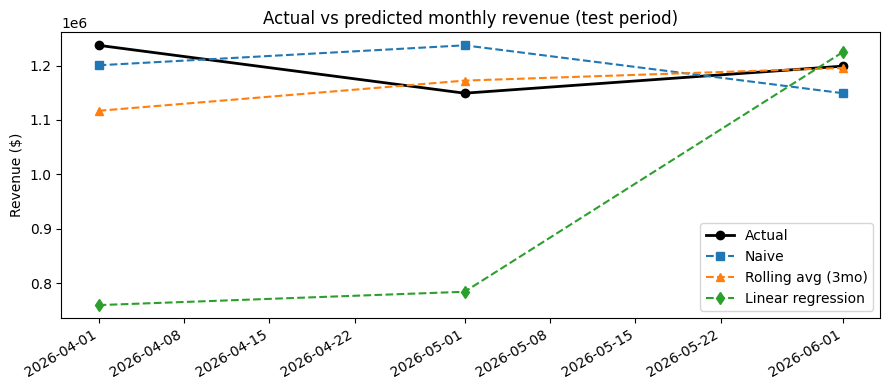

In [9]:
fig, ax = plt.subplots()
ax.plot(test["month"], test["revenue"], marker="o", label="Actual", linewidth=2, color="black")
ax.plot(test["month"], test["naive_pred"], marker="s", linestyle="--", label="Naive")
ax.plot(test["month"], test["rolling_pred"], marker="^", linestyle="--", label="Rolling avg (3mo)")
ax.plot(test["month"], test["linreg_pred"], marker="d", linestyle="--", label="Linear regression")
ax.set_title("Actual vs predicted monthly revenue (test period)")
ax.set_ylabel("Revenue ($)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Save outputs

Predictions for all three models go to `data/predictions/` for downstream
comparison in later milestones. The best-performing model (by RMSE) is
persisted to `models/` so Milestone 4 has a checked-in baseline to beat,
not just a number in a markdown cell.

In [10]:
output = test[["month", "revenue", "naive_pred", "rolling_pred", "linreg_pred"]].copy()
output = output.rename(columns={"revenue": "actual_revenue"})
out_path = PRED_DIR / "sales_forecast_baseline.csv"
output.to_csv(out_path, index=False)
print(f"Wrote {len(output)} rows to {out_path}")
output

Wrote 3 rows to ../data/predictions/sales_forecast_baseline.csv


,month,actual_revenue,naive_pred,rolling_pred,linreg_pred
0,2026-04-01,1237153.01,1200439.21,1.116776e+06,7.594328e+05
1,2026-05-01,1149116.80,1237153.01,1.172276e+06,7.839724e+05
2,2026-06-01,1198879.94,1149116.80,1.195570e+06,1.224619e+06


In [11]:
best_model_name = results["RMSE"].idxmin()
print(f"Best model by RMSE: {best_model_name}")

model_path = MODEL_DIR / "sales_forecast_baseline.pkl"
if best_model_name == "linear_regression":
    joblib.dump({"model": linreg, "features": FEATURES}, model_path)
else:
    # Naive and rolling-average "models" have no fitted parameters — persist
    # them as a plain spec so the artifact format is still consistent and
    # loadable the same way regardless of which baseline won.
    joblib.dump({"model": best_model_name, "features": FEATURES}, model_path)

print(f"Saved best model ({best_model_name}) to {model_path}")

Best model by RMSE: naive
Saved best model (naive) to ../models/sales_forecast_baseline.pkl


## Summary

**Why baseline models matter**: they set the floor. Any model proposed in
Milestone 4 onward has to beat these numbers to justify its added
complexity — otherwise a naive `next month = this month` rule is the more
maintainable choice.

**Why a time-based split**: revenue is sequential and trending, not i.i.d.
A random split would let the model train on future months and be
evaluated on past ones, which no production forecaster could ever
actually do at prediction time. The time-based split is the only one that
honestly simulates deployment.

**What performed best**: see the `results` table above — re-run this
notebook to get the current numbers rather than trusting a hardcoded
claim here, since the dataset (and therefore the winner) can change as
more months of data are generated upstream.

**Limitations**:
- Only a small number of usable months after feature warm-up, and only 3
  held out for testing — metrics here are directional, not statistically
  robust.
- No exogenous features yet (marketing spend, inventory health, the known
  Sydney anomaly) — the model can't currently explain *why* revenue moves,
  only extrapolate from its own history.
- No city-level granularity — this forecasts total company revenue, which
  can mask a Sydney-specific event exactly like the one investigated in
  Day 3/4.
- Linear regression assumes a stable linear relationship; a real trend
  break (like the Sydney anomaly) would degrade it quickly if it dominated
  the aggregate.

**Next steps**: bring in exogenous regressors from
`data/analytics/marketing_performance.csv` and
`data/analytics/store_performance.csv`; forecast at city/store grain
instead of company-wide; add a proper time-series cross-validation
(expanding window) once more historical months exist; compare against
ARIMA/Prophet once the baseline floor is well established.